In [5]:
from IPython.display import display, Math
# Configure math display settings
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Heat Pump with Expander Regulation: Thermodynamic Analysis

## Abstract

This document presents a thermodynamic analysis of a vapor compression heat pump cycle incorporating a positive displacement expander with a fixed volume ratio. We examine the relationship between expander rotational speed, expansion valve regulation, and cycle performance. The analysis provides a framework for determining optimal expansion valve settings to maintain stable operation across varying expander speeds while preserving efficient heat transfer conditions.

## 1. Introduction

Conventional vapor compression heat pumps typically employ isenthalpic expansion valves that facilitate the pressure reduction from condenser to evaporator pressure. This process, while simple to implement, results in thermodynamic losses as the expansion work potential is dissipated. Replacing the expansion valve with a positive displacement expander (such as a scroll or screw expander) allows for the partial recovery of this otherwise lost work, potentially improving overall system efficiency.

However, when implementing an expander in a heat pump cycle, several thermodynamic challenges emerge. One significant challenge is regulating the mass flow rate through the system when the expander operates at variable speeds. Unlike conventional systems where mass flow can be directly modulated via an expansion valve, a fixed volume ratio expander requires a different approach to flow regulation.

## 2. Thermodynamic Model

### 2.1 System Configuration

The heat pump system under investigation consists of the following components:
- Compressor (with isentropic efficiency $\eta_{s,comp}$)
- Condenser (with subcooling $\Delta T_{sc}$)
- Two-stage expansion system:
  - Expansion valve (producing partial pressure drop)
  - Fixed volume ratio expander (with isentropic efficiency $\eta_{s,exp}$)
- Evaporator (with superheating $\Delta T_{sh}$)

The key innovation is the two-stage expansion process that allows independent control of the mass flow rate and pressure ratio across the expander.

### 2.2 Mathematical Framework

#### 2.2.1 Expander Volumetric Flow Rate

The volumetric flow rate at the expander inlet is directly proportional to its rotational speed:

$$\dot{V}_{exp,in} = \frac{V_{disp} \cdot RPM}{60}$$

where:
- $\dot{V}_{exp,in}$ is the volumetric flow rate at expander inlet [L/s]
- $V_{disp}$ is the displacement volume per revolution [L/rev]
- $RPM$ is the rotational speed [rev/min]

#### 2.2.2 Expander Mass Flow Rate

The mass flow rate through the expander depends on the inlet density and volumetric flow rate:

$$\dot{m} = \rho_{exp,in} \cdot \dot{V}_{exp,in} \tag{2}$$

where $\rho_{exp,in}$ is the density at the expander inlet [kg/m³].

#### 2.2.3 Expansion Valve Regulation

The expansion valve creates a partial pressure drop from condenser pressure ($p_{cond}$) to an intermediate pressure ($p_{int}$). This partial expansion produces a two-phase mixture with quality $x_{valve,out}$, which becomes the expander inlet condition.

The density at the expander inlet depends on both the intermediate pressure and the vapor quality:

$$\rho_{exp,in} = \frac{1}{\frac{x_{valve,out}}{\rho_g} + \frac{1-x_{valve,out}}{\rho_l}} \tag{3}$$

where:
- $\rho_g$ is the saturated vapor density at $p_{int}$ [kg/m³]
- $\rho_l$ is the saturated liquid density at $p_{int}$ [kg/m³]
- $x_{valve,out}$ is the vapor quality at the valve outlet/expander inlet [-]

#### 2.2.4 Built-in Volume Ratio Constraint

For a fixed volume ratio expander, the ratio of specific volumes at inlet and outlet is constrained:

$$r_v = \frac{v_{exp,out}}{v_{exp,in}} \tag{4}$$

where:
- $r_v$ is the built-in volume ratio of the expander [-]
- $v_{exp,in}$ is the specific volume at expander inlet [m³/kg]
- $v_{exp,out}$ is the specific volume at expander outlet [m³/kg]

#### 2.2.5 Energy Balance

The power recovered by the expander depends on the isentropic efficiency, enthalpy difference, and mass flow rate:

$$W_{exp} = \dot{m} \cdot \eta_{s,exp} \cdot (h_{exp,in} - h_{exp,out,s}) \tag{5}$$

where:
- $W_{exp}$ is the power recovered by the expander [W]
- $h_{exp,in}$ is the specific enthalpy at expander inlet [kJ/kg]
- $h_{exp,out,s}$ is the isentropic specific enthalpy at expander outlet [kJ/kg]
- $\eta_{s,exp}$ is the isentropic efficiency of the expander [-]

## 3. Regulation Mechanism

For a heat pump with a fixed volume ratio expander, maintaining stable operation requires balancing multiple constraints:

1. The overall cycle must maintain the desired heating capacity
2. The evaporator and condenser must operate at their design temperatures
3. Appropriate superheat and subcooling must be maintained
4. The expander must operate within its mechanical limits

When the expander RPM changes, the mass flow rate through the system would naturally change according to Eq. (1) and (2). However, a stable heat pump operation requires a specific mass flow rate determined by the heating capacity and enthalpy difference across the condenser:

$$\dot{m} = \frac{Q_{cond}}{h_{cond,in} - h_{cond,out}}$$

To reconcile these constraints, the expansion valve must create a specific intermediate pressure and vapor quality that satisfies both the required mass flow rate and the expander's volumetric flow constraints.

### 3.1 Regulation Strategy

The key regulation parameter is the vapor quality after the expansion valve ($x_{valve,out}$). By adjusting this value, we can control:

1. The density at the expander inlet (affecting mass flow for a given volumetric flow)
2. The intermediate pressure between condenser and evaporator
3. The specific volume ratio across the expander

As the expander RPM increases, the volumetric flow increases proportionally. To maintain a constant mass flow rate, the density at the expander inlet must decrease, which typically requires an increase in vapor quality at the valve outlet.

### 3.2 Thermodynamic Constraints

Several thermodynamic constraints limit the feasible operating range:

1. **Minimum Vapor Quality**: The vapor quality at the expander inlet should remain above a minimum threshold (typically 0.05-0.10) to prevent liquid slugging.

2. **Maximum Expansion Ratio**: The pressure ratio across the expander should not significantly exceed its built-in volume ratio to avoid under-expansion losses.

3. **Superheat Requirement**: Sufficient superheat must be maintained at the compressor inlet to prevent liquid ingestion.

4. **Subcooling Requirement**: Adequate subcooling at the condenser outlet ensures proper expansion valve operation.

## 4. Performance Analysis

The Coefficient of Performance (COP) of the heat pump is defined as:

$$COP = \frac{Q_{cond}}{W_{comp} - W_{exp}} \tag{7}$$

where:
- $Q_{cond}$ is the heat output at the condenser [W]
- $W_{comp}$ is the compressor power consumption [W]
- $W_{exp}$ is the power recovered by the expander [W]

The optimal expander RPM and valve regulation would maximize this COP while maintaining stable operation within all thermodynamic constraints.

## 5. Numerical Solution Approach

Given the complex interrelationships between thermodynamic properties, a numerical approach is required to determine the optimal regulation parameters. The TESPy (Thermal Engineering Systems in Python) framework provides a robust solution for this analysis by:

1. Setting up the complete thermodynamic cycle with appropriate component models
2. Specifying the fixed boundary conditions (condenser/evaporator temperatures, superheat, subcooling)
3. Defining the expander volumetric flow based on RPM
4. Allowing the solver to determine the intermediate pressure and vapor quality that satisfy all constraints
5. Evaluating performance metrics for various operating conditions

Through parametric studies, we can establish the relationship between expander RPM, expansion valve setting (vapor quality), and system performance.

## 6. Conclusion

The thermodynamic analysis presented in this document provides the theoretical foundation for regulating a heat pump with a fixed volume ratio expander. By understanding the intricate relationships between volumetric flow, mass flow, pressure ratios, and vapor quality, optimal regulation strategies can be developed to maximize system efficiency across varying operating conditions.

The numerical implementation using TESPy enables comprehensive parametric studies that can inform the design of control algorithms for practical heat pump systems incorporating expanders.

In [ ]:
from HeatPumpStudy import HeatPumpStudy
from tespy.components import (
    Valve, Sink, Source, Pump, Compressor, Condenser, 
    Turbine, CycleCloser, SimpleHeatExchanger, HeatExchanger
)
from tespy.connections import Connection, Ref
from CoolProp.CoolProp import PropsSI as PSI
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

class ExpanderRegulationStudy(HeatPumpStudy):
    def __init__(
        self,
        volume_ratio=3.5,  # Built-in volume ratio of the expander
        W_in=1500,  # Mechanical Work by the compressor in W
        displacement_volume=0.01,  # L/rev
        working_fluid="R290",
        compressor_efficiency=0.7,
        expander_efficiency=0.7,
        min_rpm=200,
        max_rpm=2000,
        **kwargs
    ):
        # Expander parameters
        self.volume_ratio = volume_ratio
        self.W_in=W_in
        self.displacement_volume = displacement_volume
        self.min_rpm = min_rpm
        self.max_rpm = max_rpm
        self.results = []
        
        # Initialize with expander as expansion device
        super().__init__(
            Q_out=0, #not used in this study
            working_fluid=working_fluid,
            compressor_efficiency=compressor_efficiency,
            expander_efficiency=expander_efficiency,
            expansion_device="expander",
            **kwargs
        )
        
        # Create output directory if it doesn't exist
        if not os.path.exists("output"):
            os.makedirs("output")
            
            
    def setup_components_and_connections(self):
        """Setup heat pump components with both valve and expander"""
        
        component_list = [
            ("evaporator", SimpleHeatExchanger),
            ("compressor", Compressor),
            ("condenser", SimpleHeatExchanger),
            ("expansion_valve", Valve),
            ("expander", Turbine),
            ("post_expansion_valve", Valve),
            ("cycle_closer", CycleCloser),
        ]

        connection_list = [
            ("cycle_closer", "out1", "evaporator", "in1"),
            ("evaporator", "out1", "compressor", "in1"),
            ("compressor", "out1", "condenser", "in1"),
            ("condenser", "out1", "expansion_valve", "in1"),
            ("expansion_valve", "out1", "expander", "in1"),
            ("expander", "out1", "post_expansion_valve", "in1"),
            ("post_expansion_valve", "out1", "cycle_closer", "in1")
        ]
        
        self.add_components_and_connections(component_list, connection_list)
        return self
    
    
    def set_boundary_conditions(self, T_cond=50, T_evap=10, rpm=None, x=0.02):
        """
        Set boundary conditions for the heat pump with expander
        
        Parameters:
        -----------
        T_cond : float
            Condensation temperature in °C
        T_evap : float
            Evaporation temperature in °C
        rpm : float
            Expander RPM
        """
        # Calculate saturation pressures from temperatures
        p_cond = PSI("P", "Q", 0, "T", 273.15 + T_cond, self.working_fluid) / 1e5  # bar
        p_evap = PSI("P", "Q", 1, "T", 273.15 + T_evap, self.working_fluid) / 1e5  # bar
        
        # Set component parameters
        self.comp["evaporator"].set_attr(pr=0.98)
        
        # Ensure superheated vapor at compressor inlet with at least 5K superheat
        self.conn["evaporator-compressor"].set_attr(
            p=p_evap, 
            T=T_evap + 5,  # 5K superheat
            fluid={self.working_fluid: 1}
        )
        
        self.comp["compressor"].set_attr(eta_s=self.compressor_efficiency, P=self.W_in)
        self.comp["condenser"].set_attr(pr=0.98)
        
        # Subcooled liquid at condenser outlet
        self.conn["condenser-expansion_valve"].set_attr(
            T=T_cond - 3,  # 3K subcooling
            p=p_cond
        )
        
        # Set expander parameters
        self.comp["expander"].set_attr(eta_s=self.expander_efficiency)
        if rpm is not None:
            self.conn["expansion_valve-expander"].set_attr(x=None)
            self.conn["expander-post_expansion_valve"].set_attr(x=None)
            # Set volumetric flow at expander inlet based on RPM and displacement volume
            vol_flow = rpm * self.displacement_volume / 60  # L/s
            self.conn["expansion_valve-expander"].set_attr(v=vol_flow)
            self.conn["expander-post_expansion_valve"].set_attr(v=vol_flow*self.volume_ratio)
        else: 
            self.conn["expansion_valve-expander"].set_attr(v=None)
            self.conn["expander-post_expansion_valve"].set_attr(v=None)
            self.conn["expansion_valve-expander"].set_attr(x=x)            
            self.conn["expander-post_expansion_valve"].set_attr(x=x+0.05)
        return self
    
    def run_rpm_study(self, T_cond=50, T_evap=10, rpm_range=None):
        """
        Run parameter study varying RPM and collecting resulting vapor quality
        
        Parameters:
        -----------
        T_cond : float
            Condensation temperature in °C
        T_evap : float
            Evaporation temperature in °C
        rpm_range : list or None
            List of RPM values to test. If None, generates range from min_rpm to max_rpm
            
        Returns:
        --------
        pd.DataFrame
            DataFrame with results
        """
        if rpm_range is None:
            rpm_range = np.linspace(self.min_rpm, self.max_rpm, 10)
            
        self.results = []
        
        for rpm in rpm_range:
            # Set up the model with current RPM
            self.set_boundary_conditions(T_cond, T_evap, rpm)
            
            # Solve the model
            self.solve()
            
            # Extract results
            valve_outlet_conn = self.conn["expansion_valve-expander"]
            
            # Get vapor quality at valve outlet / expander inlet
            x_valve_out = valve_outlet_conn.x.val
            
            # Get intermediate pressure
            p_intermediate = valve_outlet_conn.p.val
            
            # Get mass flow rate
            mass_flow = valve_outlet_conn.m.val
            
            # Calculate COP
            cop = self.calculate_cop()
            
            # Store results
            self.results.append({
                "RPM": rpm,
                "Vapor_Quality": x_valve_out,
                "Intermediate_Pressure_bar": p_intermediate,
                "Mass_Flow_kg_per_s": mass_flow,
                "COP": cop
            })
            
        return self
        
    def plot_rpm_study_results(self, results_df=None, filename="output/rpm_study"):
            """
            Plot the results of the RPM study
            
            Parameters:
            -----------
            results_df : pd.DataFrame
                DataFrame with study results
            filename : str
                Base filename for saving plots
            """
            if results_df is None:
                results_df = pd.DataFrame(self.results)
            # Create figure with two subplots
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
            
            # Plot vapor quality vs RPM
            ax1.plot(results_df["RPM"], results_df["Vapor_Quality"], 'o-', linewidth=2)
            ax1.set_xlabel("Expander RPM")
            ax1.set_ylabel("Vapor Quality after Expansion Valve")
            ax1.set_title("Vapor Quality vs Expander RPM")
            ax1.grid(True)
            
            # Plot intermediate pressure vs RPM
            ax2.plot(results_df["RPM"], results_df["Intermediate_Pressure_bar"], 'o-', linewidth=2)
            ax2.set_xlabel("Expander RPM")
            ax2.set_ylabel("Intermediate Pressure (bar)")
            ax2.set_title("Intermediate Pressure vs Expander RPM")
            ax2.grid(True)
            
            plt.tight_layout()
            plt.savefig(f"{filename}.svg")
            
            # Create a second figure for COP
            plt.figure(figsize=(10, 6))
            plt.plot(results_df["RPM"], results_df["COP"], 'o-', linewidth=2)
            plt.xlabel("Expander RPM")
            plt.ylabel("COP")
            plt.title("Heat Pump COP vs Expander RPM")
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(f"{filename}_cop.svg")
            
    def run_temp_study(self, rpm=1000, T_cond_range=None, T_evap_range=None):
        """
        Run parameter study varying condenser and evaporator temperatures
        
        Parameters:
        -----------
        rpm : float
            Fixed expander RPM
        T_cond_range : list or None
            List of condenser temperatures. If None, uses default range.
        T_evap_range : list or None
            List of evaporator temperatures. If None, uses default range.
            
        Returns:
        --------
        pd.DataFrame
            DataFrame with results
        """
        if T_cond_range is None:
            T_cond_range = np.arange(50, 71, 5)
        if T_evap_range is None:
            T_evap_range = np.arange(-10, 21, 5)
            
        self.results = []
        self.rpm=rpm
        for T_cond in T_cond_range:
            for T_evap in T_evap_range:
                if T_cond <= T_evap + 20:  # Skip invalid temperature combinations
                    continue
                    
                # initialize with easy boundary conditions
                self.set_boundary_conditions(T_cond, T_evap, x=0.01)
                self.solve()
                # Set up the model with current temperatures
                self.set_boundary_conditions(T_cond, T_evap, rpm)
                
                try:
                    # Solve the model
                    self.solve(mode="design")
                    
                    # Extract results
                    valve_outlet_conn = self.conn["expansion_valve-expander"]
                    
                    # Get vapor quality at valve outlet / expander inlet
                    x_valve_out = valve_outlet_conn.x.val
                    
                    # Get intermediate pressure
                    p_intermediate = valve_outlet_conn.p.val
                    
                    # Get mass flow rate
                    mass_flow = valve_outlet_conn.m.val
                    
                    # Calculate COP
                    cop = self.calculate_cop()
                    
                    # Store results
                    self.results.append({
                        "T_cond": T_cond,
                        "T_evap": T_evap,
                        "Vapor_Quality": x_valve_out,
                        "Intermediate_Pressure_bar": p_intermediate,
                        "Mass_Flow_kg_per_s": mass_flow,
                        "COP": cop
                    })
                except Exception as e:
                    # get the error cause
                    # print the error message                    
                    print(f"Failed to solve for T_cond={T_cond}, T_evap={T_evap} due to {str(e)}")
            
        return self

    def plot_temp_study_vapor_quality(self, results_df=None, filename="output/temp_study_vapor_quality"):
        """Plot vapor quality results from temperature study as a heatmap"""
        if results_df is None:
            results_df = pd.DataFrame(self.results)
        # Pivot the DataFrame for heatmap
        pivot_df = results_df.pivot(index="T_cond", columns="T_evap", values="Vapor_Quality")
        
        plt.figure(figsize=(12, 8))
        ax = plt.gca()
        
        # Create heatmap
        im = plt.imshow(pivot_df.values, cmap="viridis", interpolation="nearest", aspect="auto")
        
        # Set ticks and labels
        plt.xticks(range(len(pivot_df.columns)), pivot_df.columns)
        plt.yticks(range(len(pivot_df.index)), pivot_df.index)
        
        # Add colorbar
        cbar = plt.colorbar(im)
        cbar.set_label("Vapor Quality after Expansion Valve")
        
        # Add text annotations with values
        for i in range(len(pivot_df.index)):
            for j in range(len(pivot_df.columns)):
                if not np.isnan(pivot_df.values[i, j]):
                    text = ax.text(j, i, f"{pivot_df.values[i, j]:.2f}",
                                    ha="center", va="center", color="w")
        
        plt.xlabel("Evaporator Temperature (°C)")
        plt.ylabel("Condenser Temperature (°C)")
        plt.title("Expansion Valve Vapor Quality vs Operating Temperatures")
        plt.tight_layout()
        plt.savefig(f"{filename}-rpm_{self.rpm}-vol_{self.displacement_volume}.svg")
        # now let's create a new figure for the vapor quality as a function of the elevation temperature (delta T). make a dot diagram
        plt.figure(figsize=(12, 8))
        plt.plot(results_df["T_cond"]-results_df["T_evap"], results_df["Vapor_Quality"], 'x', linewidth=0)
        plt.xlabel("Temperature Elevation (°K)")
        plt.ylabel("Vapor Quality after Expansion Valve")
        plt.title("Vapor Quality vs Temperature Elevation")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"{filename}-rpm_{self.rpm}-vol_{self.displacement_volume}-dT_X.svg")
        plt.show()
        
        

ImportError: cannot import name 'SimpleHeatExchanger' from 'tespy.components' (c:\Users\Ilewicz\AppData\Local\Programs\Python\Python311\Lib\site-packages\tespy\components\__init__.py)

flow at expander inlet is :0.06744272526679178 l/s
at :2000 rpm this would be a displacement volume of 0.0020232817580037536 l/rev
at :200 rpm this would be a displacement volume of 0.020232817580037536 l/rev
the volume ratio between before and after the expander is :1.367037450429926
that amounts to a total volume flow at the expansion valve inlet of 1.524465522641198 l/min
and a total volume flow before the compressor of 39.27330359781392 l/min
in total the massflow is :39.24347042193857 kg/h


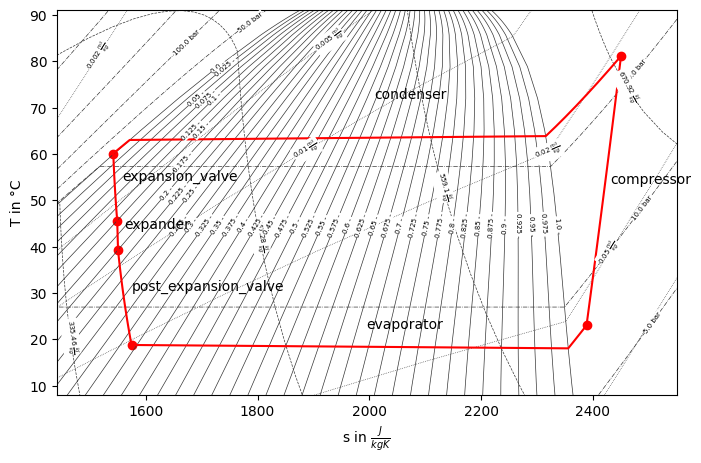

In [ ]:
study = ExpanderRegulationStudy(
    ).set_boundary_conditions(x=0.15, T_cond=63, T_evap=18
    ).solve()
print(f"flow at expander inlet is :{study.conn['expansion_valve-expander'].v.val} l/s")
rpm=2000
print(f"at :{rpm} rpm this would be a displacement volume of {study.conn['expansion_valve-expander'].v.val*60/rpm} l/rev")
rpm=200
print(f"at :{rpm} rpm this would be a displacement volume of {study.conn['expansion_valve-expander'].v.val*60/rpm} l/rev")
print(f"the volume ratio between before and after the expander is :{study.conn['expander-post_expansion_valve'].v.val/study.conn['expansion_valve-expander'].v.val}")

print(f"that amounts to a total volume flow at the expansion valve inlet of {study.conn['condenser-expansion_valve'].v.val*60} l/min")
print(f"and a total volume flow before the compressor of {study.conn['evaporator-compressor'].v.val*60} l/min")
print(f"in total the massflow is :{study.conn['evaporator-compressor'].m.val*60*60} kg/h")
study.plot_ts_diag(filename="expander_regulation_ts")


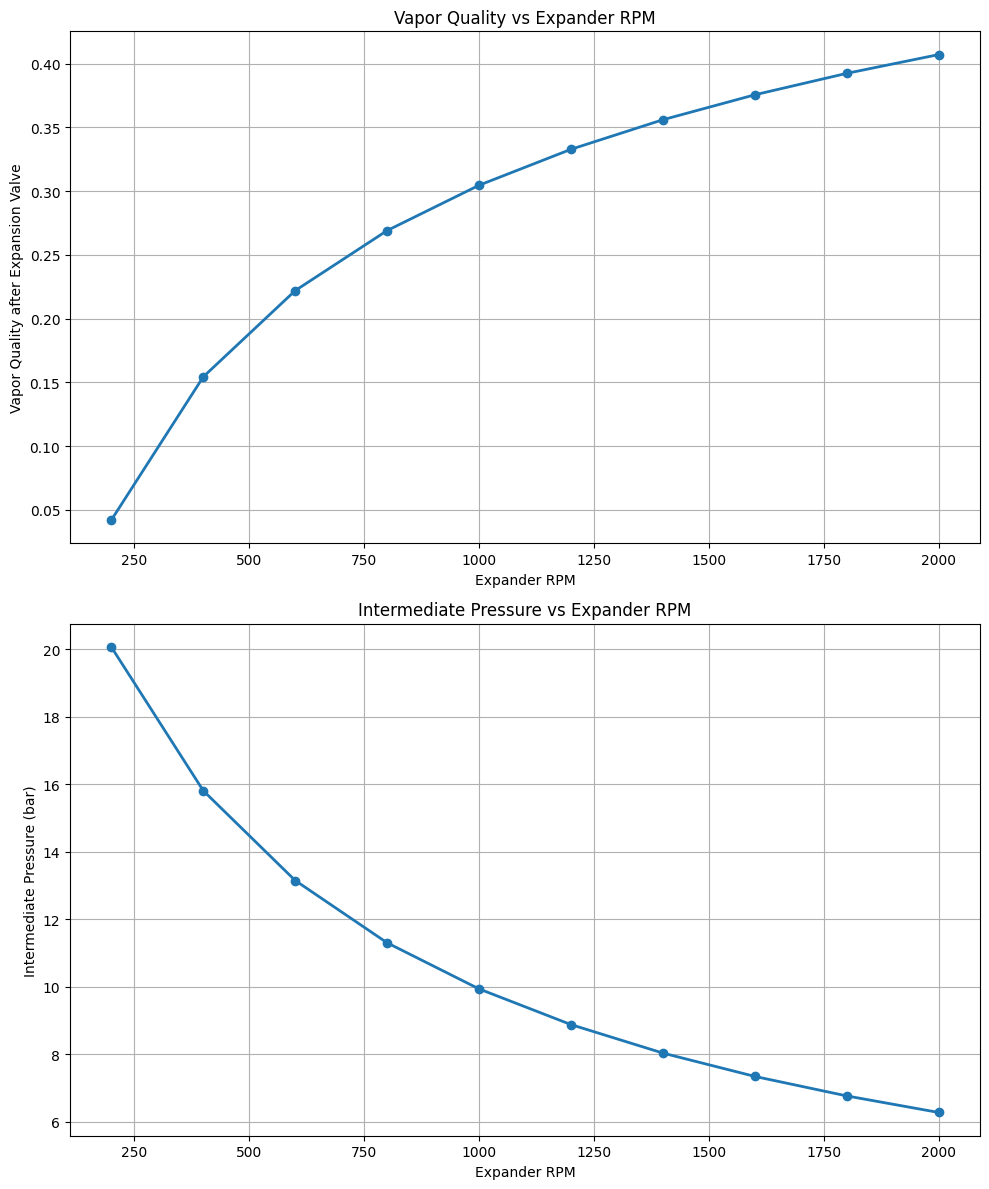

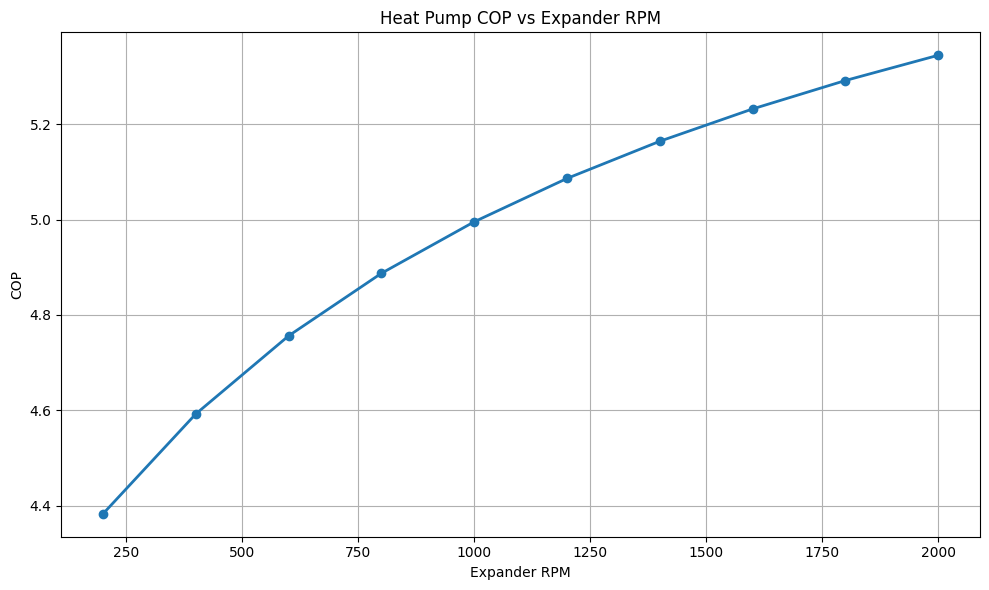

In [ ]:
study.run_rpm_study(T_cond=64, T_evap=18)
study.plot_rpm_study_results()

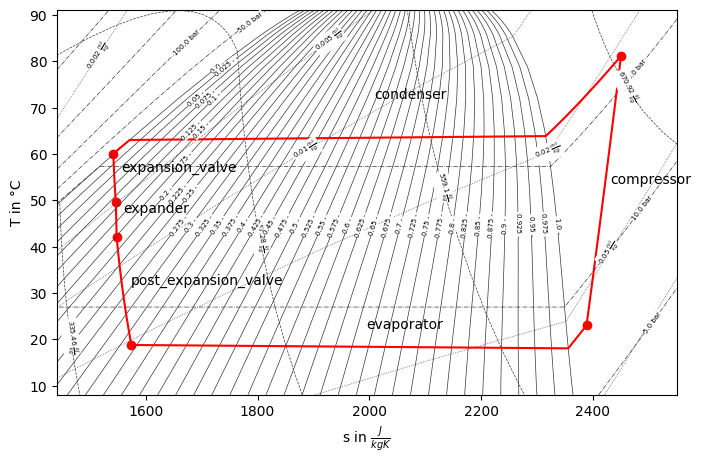

In [ ]:
study=ExpanderRegulationStudy(volume_ratio=1.5, 
                        displacement_volume=0.012
).set_boundary_conditions(
    T_cond=63, T_evap=18, rpm=400
).solve()
study.plot_ts_diag(filename="expander_regulation_ts_2")
                        

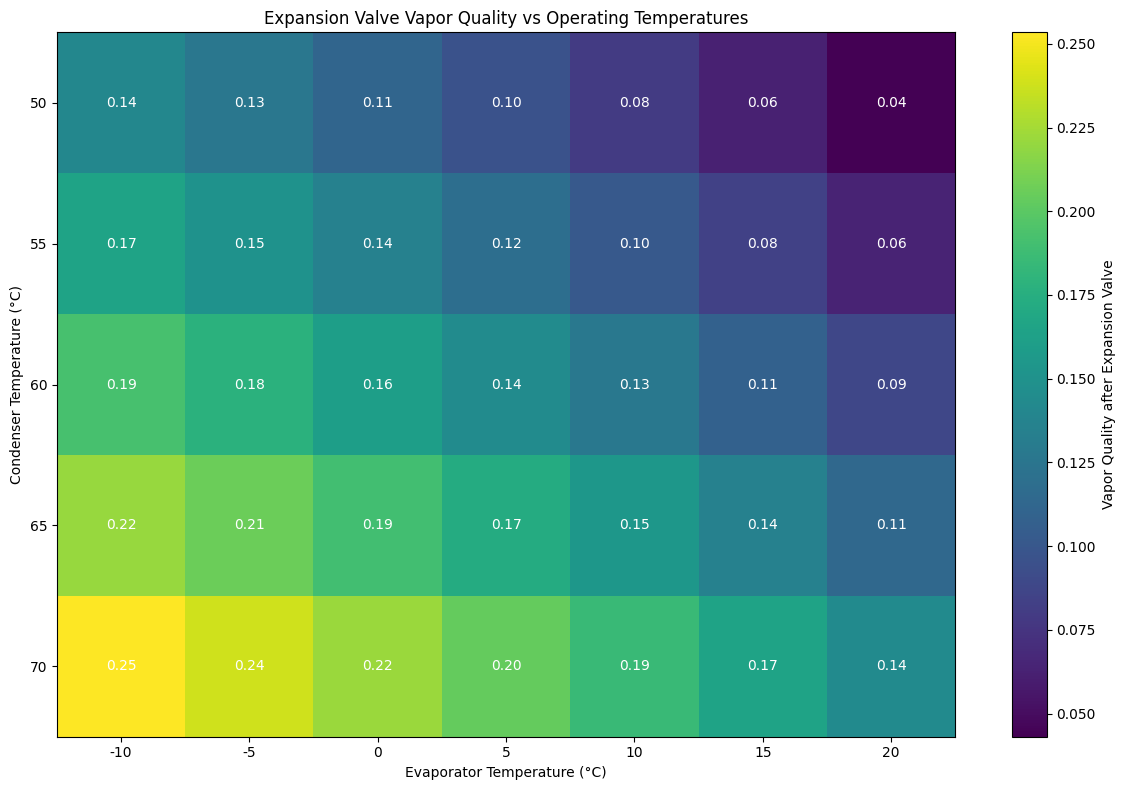

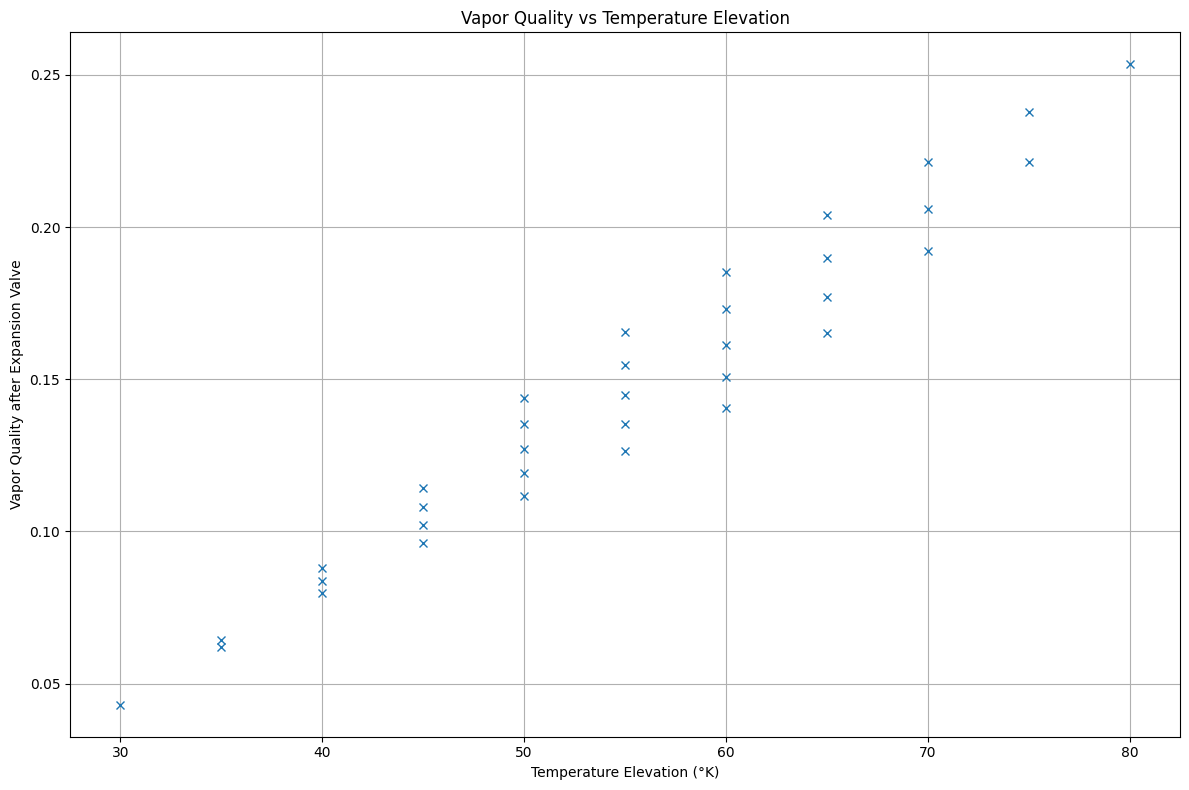

In [ ]:
ExpanderRegulationStudy(volume_ratio=1.5, 
                        displacement_volume=0.008
                        ).run_temp_study(
                            rpm=400
                        ).plot_temp_study_vapor_quality()